In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # 0=all messages, 1=information, 2=warning, 3=error

env_path = sys.prefix
os.environ['CC'] = f"{env_path}/bin/x86_64-conda-linux-gnu-cc"
os.environ['CXX'] = f"{env_path}/bin/x86_64-conda-linux-gnu-c++"

os.environ['PKG_CONFIG_PATH'] = f"{env_path}/lib/pkgconfig"
os.environ['LD_LIBRARY_PATH'] = f"{env_path}/lib"


import numpy as np
import matplotlib.pyplot as plt
from fenics import *

from src.physics import constants as c
from src.visualization.pdeplots import N_GRID
os.makedirs('data/fem', exist_ok=True)

2026-09-10 15:30:55.299085: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789047055.313593  135228 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789047055.318262  135228 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1789047055.330394  135228 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789047055.330406  135228 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1789047055.330408  135228 computation_placer.cc:177] computation placer alr

In [2]:
# MESH
nx, ny = 400, 400
mesh = UnitSquareMesh(nx,ny) 
V = FunctionSpace(mesh, 'CG', 1)

# BOUNDARY CONDITIONS
b_markers = MeshFunction('size_t', mesh, mesh.topology().dim() - 1)
b_markers.set_all(0) 


r = c.R_A_VAL
for f in facets(mesh):
    if f.exterior(): 
        x = f.midpoint().x()
        y = f.midpoint().y()
        dist = np.sqrt(x**2 + y**2)
        if np.isclose(dist, 0.0, atol=r):
            b_markers[f] = 1

psi_activation = Constant(0.0)
bc = DirichletBC(V, psi_activation, b_markers, 1)

v_teo = 62.0 * np.sqrt(1.529) 
u_initial = Expression(f'sqrt(pow(x[0] - x0, 2) + pow(x[1] - y0, 2)) / {v_teo}', degree=1, x0=0.0, y0=0.0)

N_points = N_GRID
x_test = np.linspace(0.0, 1.0, N_points)
y_test = np.linspace(0.0, 1.0, N_points)
X_test, Y_test = np.meshgrid(x_test, y_test)
X_test_flattened = np.hstack((X_test.flatten()[:, None], Y_test.flatten()[:, None]))
coords_fem = V.tabulate_dof_coordinates()

In [3]:
def solve_and_save(M_tensor, name):
    print(f"Solving FEM for tensor: {name.upper()}")

    psi = Function(V)
    v = TestFunction(V)
    psi.interpolate(u_initial)

    eps = Constant(c.EPS_VAL)
    c0 = Constant(c.C0_VAL)

    grad_psi = grad(psi)
    M_grad_psi = M_tensor * grad_psi
    norm_term = sqrt(inner(grad_psi, M_grad_psi))
    F = (c0 * norm_term * v * dx + eps * inner(M_grad_psi, grad(v)) * dx - Constant(1.0) * v * dx)

    J = derivative(F, psi)
    pb = NonlinearVariationalProblem(F, psi, bc, J)
    solver = NonlinearVariationalSolver(pb)

    prm = solver.parameters
    prm['newton_solver']['linear_solver'] = 'gmres'
    prm['newton_solver']['preconditioner'] = 'amg'

    prm['newton_solver']['absolute_tolerance'] = 1E-8
    prm['newton_solver']['relative_tolerance'] = 1E-7
    prm['newton_solver']['maximum_iterations'] = 50
    prm['newton_solver']['error_on_nonconvergence'] = False

    n_it, converged = solver.solve()
    if converged:
        print(f"converged in {n_it} iterations.")
    else:
        print(f"Did not converge in {n_it} iterations")

    values_fem = psi.vector().get_local().reshape(-1, 1)
    np.savez(f'data/fem/fem_train_data_{name}.npz', coords=coords_fem, values=values_fem)

    print("Validating grid for inference plots...")
    u_fem_grid = np.array([psi(pt) for pt in X_test_flattened])
    np.save(f'data/fem/fem_grid_{name}.npy', u_fem_grid)

    plt.figure(figsize=(8, 6))
    mappa = plot(psi*(1e3), title=f"FEM solution {name.upper()}")
    plt.colorbar(mappa, label="Time [ms]")
    plot(psi, mode="contour", colors="black", linewidths=0.5)
    plt.xlabel("X [cm]")
    plt.ylabel("Y [cm]")
    plt.show()

    return psi

Solving FEM for tensor: CONST
converged in 3 iterations.
Solving nonlinear variational problem.
  Newton iteration 0: r (abs) = 9.433e-03 (tol = 1.000e-08) r (rel) = 1.000e+00 (tol = 1.000e-07)
  Newton iteration 1: r (abs) = 9.873e-05 (tol = 1.000e-08) r (rel) = 1.047e-02 (tol = 1.000e-07)
  Newton iteration 2: r (abs) = 5.237e-07 (tol = 1.000e-08) r (rel) = 5.552e-05 (tol = 1.000e-07)
  Newton iteration 3: r (abs) = 1.542e-11 (tol = 1.000e-08) r (rel) = 1.635e-09 (tol = 1.000e-07)
  Newton solver finished in 3 iterations and 12 linear solver iterations.
Validating grid for inference plots...
Object cannot be plotted directly, projecting to piecewise linears.


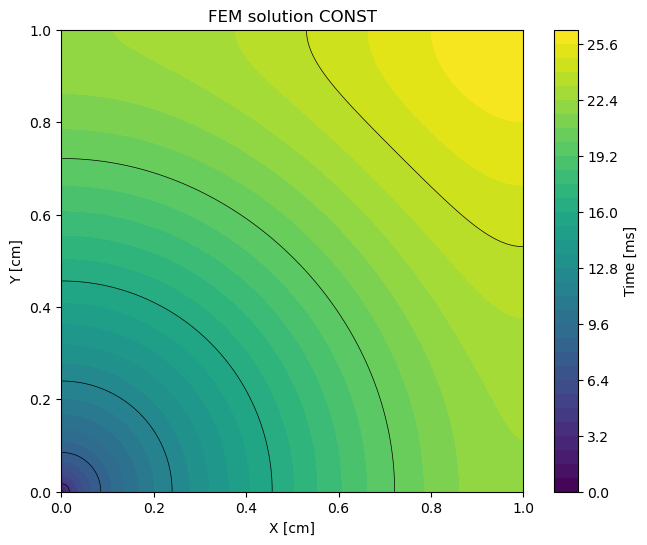

Solving FEM for tensor: NON_CONST
Solving nonlinear variational problem.
converged in 8 iterations.
  Newton iteration 0: r (abs) = 1.054e-02 (tol = 1.000e-08) r (rel) = 1.000e+00 (tol = 1.000e-07)
  Newton iteration 1: r (abs) = 3.444e-03 (tol = 1.000e-08) r (rel) = 3.266e-01 (tol = 1.000e-07)
  Newton iteration 2: r (abs) = 6.917e-04 (tol = 1.000e-08) r (rel) = 6.560e-02 (tol = 1.000e-07)
  Newton iteration 3: r (abs) = 2.341e-04 (tol = 1.000e-08) r (rel) = 2.220e-02 (tol = 1.000e-07)
  Newton iteration 4: r (abs) = 8.141e-05 (tol = 1.000e-08) r (rel) = 7.721e-03 (tol = 1.000e-07)
  Newton iteration 5: r (abs) = 2.370e-05 (tol = 1.000e-08) r (rel) = 2.247e-03 (tol = 1.000e-07)
  Newton iteration 6: r (abs) = 3.534e-06 (tol = 1.000e-08) r (rel) = 3.352e-04 (tol = 1.000e-07)
  Newton iteration 7: r (abs) = 5.973e-08 (tol = 1.000e-08) r (rel) = 5.665e-06 (tol = 1.000e-07)
  Newton iteration 8: r (abs) = 4.109e-12 (tol = 1.000e-08) r (rel) = 3.897e-10 (tol = 1.000e-07)
  Newton solver fi

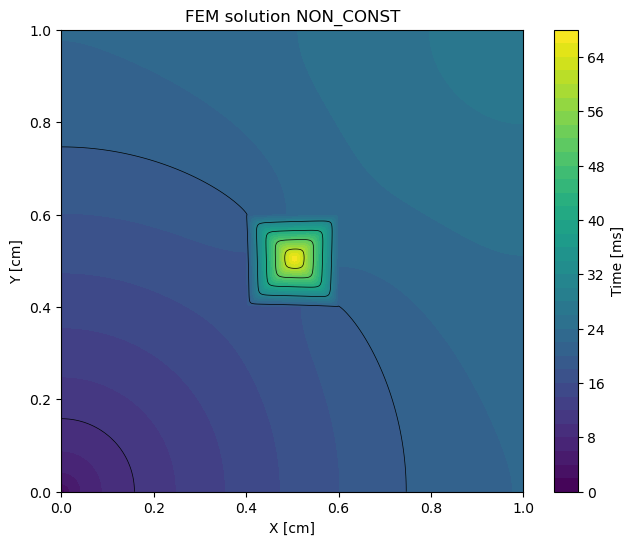

In [4]:
# Solve for constant M (not used in the PINN training, used only for comparison)
M_const = Constant(c.M_VAL)
psi_const = solve_and_save(M_const, "const")

M = Expression(
    '(x[0] >= x_min && x[0] <= x_max && x[1] >= y_min && x[1] <= y_max) ? m_scar : m_normal',
    degree=0,
    x_min=c.SCAR_X_MIN, x_max=c.SCAR_X_MAX,
    y_min=c.SCAR_Y_MIN, y_max=c.SCAR_Y_MAX,
    m_scar=c.M_SCAR, m_normal=c.M_VAL
)
psi = solve_and_save(M, "non_const")